# TD 4 : Test de comparaison d'une moyenne observée à une moyenne théorique

Christelle Gonindard, Matthais Grenié, François Bettega

<div class="alert alert-info">

## Objectifs

- Faire la différence entre un test bilatéral et un test unilatéral
- Connaître les conditions d'application d'un test de comparaison de moyenne observée à une moyenne théorique
- Apprendre à mettre en œuvre un test de Student pour comparer une moyenne observée à une moyenne théorique
- Interpréter le résultat de ce test

</div>

## 1. Présentation des données

Un clinicien évalue l’intensité de la dépression sur l’échelle de Hamilton qui varie de 0 (non
déprimé) à 56 (très déprimé), chez 100 patients souffrant d’un Episode Dépressif Majeur (EDM).
On veut savoir si l’acupuncture améliore l’évolution de la dépression. Pour cela, 100 malades
de même état dépressif (même score de Hamilton) sont répartis en 2 groupes de 50 par tirage
au sort. Le groupe I a reçu uniquement le traitement pharmacologique et le groupe II a reçu le
traitement pharmacologique associé à de l’acupuncture.

Le jeu de données contient les variables suivantes en colonne :
- `hamilton_g1` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 1 ;
- `hamilton_g2` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 2 ;
- `age_g1` : l’âge des patients du groupe 1 ;
- `age_g2` : l’âge des patients du groupe 2 ;
- `poids_g1` : le poids des patients du groupe 1 ;
- `poids_g2` : le poids des patients du groupe 2 ;
- `sexe_g1` : le sexe des patients du groupe 1 (`"F"` : femme, `"H"` : homme) ;
- `sexe_g2` : le sexe des patients du groupe 2 (`"F"` : femme, `"H"` : homme) ;
- `urbanisation_g1` : le niveau d’urbanisation dans lequel vivent les patients du groupe 1 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé) ;
- `urbanisation_g2` : le niveau d’urbanisation dans lequel vivent les patients du groupe 2 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé).

Les données sont contenues dans le fichier texte nommé `depression.txt` qui se trouve dans le dossier `data`. Le chemin d'accès complet du fichier est donc `data/depression.txt`.

In [1]:
depression <- read.table("data/depression.txt", header = TRUE)

# Afficher le début du contenu du fichier de données 
head(depression)

# chargement des fonctions dont vous aurez besoin (à partir de maintenant pensez à l'ajouter vous même 
# dans les TD suivants)
CI <- function(x, confidence){
    alpha = 1 - confidence
    mu = mean(x)
    sigma = sd(x)
    n = length(x)
    CI_inf = mu - (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI_sup = mu + (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI = c(inf = CI_inf, sup = CI_sup) 
    return(CI)
}

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,43,25,B,B,57,48,74,93,F,H
2,29,29,A,B,37,41,95,92,H,H
3,34,18,A,A,7,30,84,86,H,H
4,39,23,A,A,37,41,104,81,H,H
5,40,24,B,A,15,30,92,74,H,F
6,41,25,B,B,45,45,85,98,H,H


## 2. Test bilatéral 

**Objectif : On voudrait savoir si les scores de Hamilton observés dans le groupe 1 chez les
femmes sont égaux en moyenne à 29.**

### Principe

Nous devons réaliser un [test de Student](https://fr.wikipedia.org/wiki/Test_de_Studenthttps://fr.wikipedia.org/wiki/Test_de_Student) comparant la moyenne estimée par la fonction
`mean()` avec la moyenne théorique escomptée $E = 29$ dans notre cas.

On va réaliser un test statistique qui va vérifier si l’écart entre la moyenne observée $\mu$ dans
l’échantillon et la moyenne théorique $\mu_0$. S'il est suffisamment éloigné de 0 avec un certain
risque d’erreur $\alpha$ alors on considère que les deux moyennes sont différentes.

Le test calcule la valeur $T$ qui est la différence entre $\mu$ et $\mu_0$ et divise par son écart-type pour normaliser :

$$ T = \frac{\mu - \mu_0}{\sqrt{\frac{S ^2}{n} }}$$

avec $S$ l'écart-type de notre échantillon et $n$ la taille de notre échantillon.
On voit avec l'équation ci-dessus que plus l'écart entre la moyenne observée et la moyenne théorique est grand, pour une taille d'échantillon donné, plus la valeur $T$ va être grande. Inversement, plus l'écart sera petit, plus la valeur de $T$ sera petite.

On parle de test **bilatéral**, car notre test ne conclue sur la **direction** de la différence entre la moyenne observée et la moyenne théorique. Il teste seulement si $\mu$ est différent de $\mu_0$, mais pas si $\mu$ est supérieure ou inférieure à $\mu_0$.

On peut visualiser le test de la façon suivante :

<img src="figures/Test_bilateral.jpg" />

Pour notre exemple, les **hypothèses du test** sont :

H0 : le score de Hamilton chez les femmes du groupe 1 est égal à 29.

H1 : le score de Hamilton chez les femmes du groupe 1 n’est pas égal à 29.

*Application : Extrayez l'échantillon et calculez sa taille avec la fonction `length()`*

In [2]:
# Extraction des données
femme_g1 = depression$hamilton_g1[depression$sexe_g1 == "F"]

# Affichage des données extraites
femme_g1

# taille de l'échantillon
length(femme_g1)

[1] 43 37 38 40 37 41 43 47 46 42 44

[1] 11

<div class="alert alert-danger" role="alert">

### Conditions d'application

Pour réaliser le test de Student de comparaison d'une moyenne observée à une moyenne théorique il fait vérifier une condition d'application qui dépend de la taille de l'échantillon :
- Si la taille de l’échantillon est grande ($n \geq 30$) : pas de condition d’application à vérifier, on peut réaliser le test directement ;
- Si la taille de l’échantillon est petite ($n < 30$) : il faut que les données suivent une loi normale

</div>

Comme on observe que $n = 11$, on doit vérifier la normalité des données de notre échantillon. On peut le faire avec le test de Shapiro-Wilk

Rappel des hypothèses du test de Shapiro

H0 : ???

H1 : ???

In [3]:
shapiro.test(femme_g1)


	Shapiro-Wilk normality test

data:  femme_g1
W = 0.94764, p-value = 0.614


**Conclusion :**

On observe p = 0.61 > alpha = 0.05, donc on ne peut pas rejeter l’hypothèse H0, ce qui signifie que les données suivent une loi normale.

### Réalisation du test

Pour réaliser le test de Student, on utilise la fonction `t.test()` qui prend comme premier argument l'échantillon à tester et un argument `mu=` qui est la valeur de la moyenne théorique avec laquelle le comparer.

In [4]:
t.test(femme_g1, mu = 29)


	One Sample t-test

data:  femme_g1
t = 12.276, df = 10, p-value = 2.358e-07
alternative hypothesis: true mean is not equal to 29
95 percent confidence interval:
 39.34289 43.92984
sample estimates:
mean of x 
 41.63636 


**Conclusion** :

On observe p = 2.3⋅10⁻⁷ < alpha = 0.05, donc on rejette l’hypothèse H0, ce qui signifie que le score de
Hamilton pour les femmes du groupe 1 est différent de 29.

## 3. Test unilatéral

**Objectif : On voudrait savoir si les scores de Hamilton observés dans le groupe 1 chez les
femmes sont supérieurs en moyenne à 29**

### Principe

On différencie les tests **unilatéraux** des tests bilatéraux car il teste le **sens** de la différence entre l'échantillon et l'attendu.
Dans le cas du test de Student, on peut tester si la moyenne observée est **supérieure** ou bien tester si elle est **inférieure** à la moyenne théorique.

<img src="figures/Test_unilateral.jpg" />

Dans ce cas, nous allons réaliser un test unilatéral :

H0 : le score de Hamilton chez les femmes du groupe 1 est égal à 29.

H1 : le score de Hamilton chez les femmes du groupe 1 est supérieur à 29.

### Conditions d'application

Ce sont les même conditions d'application que pour le test bilatéral et donc elles ont déjà été vérifiées

### Réalisation du test

Pour réaliser un test unilatéral il faut spécifier à la fonction `t.test()` l'argument `alternative=`. Cela signifie qu'on change d'hypothèse **alternative**. Cet argument peut prendre trois valeurs :

- Par défaut, cet argument vaut la valeur `"two.sided"`, ce qui correspond à un test bilatéral.
- `"greater"`, cela signifie qu'on teste si notre moyenne observée est **supérieure** à la moyenne théorique (*greater* en anglais).
- `"less"`, cela signifie qu'on teste si notre moyenne observée est **inférieure** à la moyenne théorique (*less* en anglais).

Donc pour réaliser notre unilatéral il faut donner à la fonction `t.test()` :
- notre échantillon,
- l'argument `mu = 29` pour préciser la valeur de la moyenne théorique,
- l'argument `alternative = "greater"` pour préciser que l'on veut tester si notre moyenne observée est supérieure à 29.

*Réalisez le test*

In [5]:
t.test(femme_g1, mu = 29, alternative = "greater")


	One Sample t-test

data:  femme_g1
t = 12.276, df = 10, p-value = 1.179e-07
alternative hypothesis: true mean is greater than 29
95 percent confidence interval:
 39.77076      Inf
sample estimates:
mean of x 
 41.63636 


**Conclusion** :

Au seuil 5%, la pvalue < 0.05 donc on rejete l’hypothèse H0 donc le score de
Hamilton pour les femmes du groupe 1 est supérieur à 39.

<div class="alert alert-success">

## En résumé

Dans cette séance :

- Nous avons appris à effectuer un test de Student avec la fonction `t.test()`, avec l'argument `mu = ` qui donne la moyenne théorique
- Nous avons appris les conditions d'application des tests de Student de comparaison à une moyenne théorique : si $n \geq 30$, on peut directement procéder au test ; sinon, il faut vérifier la normalité de l'échantillon
- Nous avons appris la différence entre test **bilatéral** et **unilatéral** : un test bilatéral ne donne pas d'information sur le sens de la différence testée alors qu'un test unilatéral permet de savoir si la moyenne observée est soit supérieure soit inférieure à la moyenne théorique
- Pour réaliser un test bilatéral on peut utiliser la fonction `t.test()` directement ou en spécifiant l'argument `alternative = "two.sided"`
- Pour réaliser un test unilatéral on doit spécifier `alternative = "greater"`, pour tester si la moyenne observée est supérieure à la moyenne théorique ; `alternative = "less"` pour tester si la moyenne observée est inférieure à la moyenne théorique

</div>

## 4. Exercices d'application

###  Exercice 1

Répondez aux questions suivantes, les tests seront réalisés au seuil $\alpha=0.02$ :

1. Est ce que les scores de Hamilton observés dans le groupe 2 chez les femmes est inférieur en moyenne à 29?
2. Est ce que les scores de Hamilton observés dans le groupe 1 chez les hommes est supérieur en moyenne à 29?
3. Est ce que les scores de Hamilton observés dans le groupe 2 chez les hommes est supérieur en moyenne à 29?
4. Est ce que les scores de Hamilton observés dans le groupe 1 chez les femmes est supérieur en moyenne à 29?

Concluez.


In [6]:
# Création des groupes 

f_g1 = depression$hamilton_g1[depression$sexe_g1 == "F"]
f_g2 = depression$hamilton_g2[depression$sexe_g2 == "F"]
h_g1 = depression$hamilton_g1[depression$sexe_g1 == "H"]
h_g2 = depression$hamilton_g2[depression$sexe_g2 == "H"]

length(f_g1)
length(f_g2)
length(h_g1)
length(h_g2)

# => condition à vérifier poru les femmes seulement

shapiro.test(f_g1)
shapiro.test(f_g2)

# 1. Est ce que les scores de Hamilton observés dans le groupe 2 chez les femmes est inférieur en moyenne à 29? 

# H0 : le score de Hamilton chez les femmes du groupe 2 est égal à 29.
# H1 : le score de Hamilton chez les femmes du groupe 2 est inférieur à 29.

t.test(f_g2, mu = 29, alternative = "less")


# 2. Est ce que les scores de Hamilton observés dans le groupe 1 chez les hommes est superieur en moyenne à 29?

# H0 : le score de Hamilton chez les hommes du groupe 1 est égal à 29.
# H1 : le score de Hamilton chez les hommes du groupe 1 est supérieur à 29.

t.test(h_g1,mu=29,alternative="greater")

# 3. Est ce que les scores de Hamilton observés dans le groupe 2 chez les hommes est supérieur en moyenne à 29?

# H0 : le score de Hamilton chez les hommes du groupe 2 est égal à 29.
# H1 : le score de Hamilton chez les hommes du groupe 2 est inférieur à 29.

t.test(h_g1,mu=29,alternative="greater")

# 4. Est ce que les scores de Hamilton observés dans le groupe 1 chez les femmes est supérieur en moyenne à 29?


# H0 : le score de Hamilton chez les femmes du groupe 1 est égal à 29.
# H1 : le score de Hamilton chez les femmes du groupe 1 est supérieur à 29.

t.test(f_g1,mu=29,alternative="greater")


[1] 11

[1] 5

[1] 39

[1] 45


	Shapiro-Wilk normality test

data:  f_g1
W = 0.94764, p-value = 0.614



	Shapiro-Wilk normality test

data:  f_g2
W = 0.96258, p-value = 0.8258



	One Sample t-test

data:  f_g2
t = -1.7233, df = 4, p-value = 0.07997
alternative hypothesis: true mean is less than 29
95 percent confidence interval:
     -Inf 29.99576
sample estimates:
mean of x 
     24.8 



	One Sample t-test

data:  h_g1
t = 11.251, df = 38, p-value = 5.846e-14
alternative hypothesis: true mean is greater than 29
95 percent confidence interval:
 36.62952      Inf
sample estimates:
mean of x 
 37.97436 



	One Sample t-test

data:  h_g1
t = 11.251, df = 38, p-value = 5.846e-14
alternative hypothesis: true mean is greater than 29
95 percent confidence interval:
 36.62952      Inf
sample estimates:
mean of x 
 37.97436 



	One Sample t-test

data:  f_g1
t = 12.276, df = 10, p-value = 1.179e-07
alternative hypothesis: true mean is greater than 29
95 percent confidence interval:
 39.77076      Inf
sample estimates:
mean of x 
 41.63636 


### Exercice 2 (à faire à la maison pour s'entrainer)

Répondez aux questions suivantes, les tests seront réalisés au seuil $\alpha=0.01$ :

1. Est-ce que les scores de Hamilton observés dans le groupe 2 dans les zones rurales sont différents en moyenne à 29?
2. Est-ce que les scores de Hamilton observés dans le groupe 2 dans les zones à urbanisation modéré sont différents en moyenne à 29?
3. Est-ce que les scores de Hamilton observés dans le groupe 2 dans les zones fortement urbanisées sont inférieurs en moyenne à 25?


4. Est-ce que les scores de Hamilton observés dans le groupe 1 dans les zones rurales sont inférieurs en moyenne à 39?
5. Est-ce que les scores de Hamilton observés dans le groupe 1 dans les zones à urbanisation modéré sont supérieurs en moyenne à 29?
6. Est-ce que les scores de Hamilton observés dans le groupe 1 dans les zones fortement urbanisées sont différents en moyenne à 25?

Concluez.

In [7]:
# Est-ce que les scores de Hamilton observés dans le groupe 2 dans les zones rurales 
# sont différents en moyenne à 29?

head(depression)

table(depression$urbanisation_g2)

echA=depression$hamilton_g2[depression$urbanisation_g2=="A"]
length(echA)

shapiro.test(echA)

# => condition vérifier car alpha = 0.01 

# H0 : le score de Hamilton du groupe 2 dans les zones A est égal à 29.
# H1 : le score de Hamilton du groupe 2 dans les zones A est différent de 29.


t.test (echA,mu=29)

# => différence au seuil 1%

# 2. Est-ce que les scores de Hamilton observés dans le groupe 2 dans les zones à urbanisation modéré 
# sont différents en moyenne à 29?

echB=depression$hamilton_g2[depression$urbanisation_g2=="B"]
length(echB)

shapiro.test(echB)

# => condition vérifier car alpha = 0.01 

# H0 : le score de Hamilton du groupe 2 dans les zones B est égal à 29.
# H1 : le score de Hamilton du groupe 2 dans les zones B est différent de 29.


t.test (echB,mu=29)

# => pas de différence au seuil 1%

# 3. Est-ce que les scores de Hamilton observés dans le groupe 2 dans les zones fortement urbanisées sont inférieurs en moyenne à 25?

# => impossible à réaliser car pas de classes C dans l'échantillon



# 4. Est-ce que les scores de Hamilton observés dans le groupe 1 dans les zones rurales 
# sont inférieurs en moyenne à 39?

echA=depression$hamilton_g1[depression$urbanisation_g1=="A"]
length(echA)

shapiro.test(echA)

# => condition vérifier car alpha = 0.01 

# H0 : le score de Hamilton du groupe 2 dans les zones A est = 39.
# H1 : le score de Hamilton du groupe 2 dans les zones A est < 39.


t.test (echA,mu=39,alternative="less")

# => moyenne < 39 au seuil 1%

# 5. Est-ce que les scores de Hamilton observés dans le groupe 1 dans les zones à 
# urbanisation modéré sont supérieurs en moyenne à 29?


echB=depression$hamilton_g1[depression$urbanisation_g1=="B"]
length(echB)

shapiro.test(echB)

# H0 : le score de Hamilton du groupe 2 dans les zones B est égal à 29.
# H1 : le score de Hamilton du groupe 2 dans les zones B est > 29.

t.test (echB,mu=29,alternative="greater")


# => moyenne < 29 au seuil 1%

# 6. Est-ce que les scores de Hamilton observés dans le groupe 1 dans les zones fortement 
# urbanisées sont différents en moyenne à 25?


echC=depression$hamilton_g1[depression$urbanisation_g1=="C"]
length(echC)

shapiro.test(echC)

# H0 : le score de Hamilton du groupe 2 dans les zones C est égal à 25.
# H1 : le score de Hamilton du groupe 2 dans les zones C est différent de 25.

t.test (echC,mu=25)


# => moyenne différente de 25 au seuil 1%


,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,43,25,B,B,57,48,74,93,F,H
2,29,29,A,B,37,41,95,92,H,H
3,34,18,A,A,7,30,84,86,H,H
4,39,23,A,A,37,41,104,81,H,H
5,40,24,B,A,15,30,92,74,H,F
6,41,25,B,B,45,45,85,98,H,H



 A  B 
24 26 

[1] 24


	Shapiro-Wilk normality test

data:  echA
W = 0.8847, p-value = 0.01035



	One Sample t-test

data:  echA
t = -13.431, df = 23, p-value = 2.26e-12
alternative hypothesis: true mean is not equal to 29
95 percent confidence interval:
 19.0466 21.7034
sample estimates:
mean of x 
   20.375 


...


	Shapiro-Wilk normality test

data:  echB
W = 0.88686, p-value = 0.01962



	One Sample t-test

data:  echB
t = 39.957, df = 20, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 29
95 percent confidence interval:
 41.34773      Inf
sample estimates:
mean of x 
 41.90476 


[1] 5


	Shapiro-Wilk normality test

data:  echC
W = 0.88104, p-value = 0.314



	One Sample t-test

data:  echC
t = 28.597, df = 4, p-value = 8.899e-06
alternative hypothesis: true mean is not equal to 25
95 percent confidence interval:
 44.3223 48.4777
sample estimates:
mean of x 
     46.4 


## 5. Exercices supplémentaires

Cette partie vous permettra de réviser tout ce que nous avons fait au cours des trois premiers TDs. 

Le fichier de données `insurance.txt`, que nous allons analyser, est constitué des données clients suivantes:

- `age` : âge du principal bénéficiaire
- `sex` : sexe de l'assureur, féminin, masculin
- `bmi` : indice de masse corporelle (***b**ody **m**ass **i**ndex* en anglais), permettant de comprendre le corps, les poids relativement élevés ou faibles par rapport à la taille, indice objectif du poids corporel (kg/m^2) utilisant le rapport taille/poids, idéalement 18,5 à 24,9
-  `children` : Nombre d'enfants couverts par l'assurance maladie / Nombre de personnes à charge
- `smoker` : fumeur (`"yes"`) ou non (`no`)
- `region` : zone de résidence du bénéficiaire aux États-Unis (`"northeast"` = Nord-Est ;  `"northwest"` = Nord-Ouest ; `"southeast"` = Sud-Est ; `"southwest"` = Sud-Ouest)
- `charges` : Frais médicaux individuels facturés par l'assurance maladie


### Exercice 3 : Description de données + Intervalles de confiance

Répondez aux questions suivantes, les tests seront réalisés au seuil $\alpha=0.05$ :

1. Charger le jeu de données "insurance.txt"
2. Présenter la table des effectifs croisés entre fumeurs et la région.
3. Calculer la moyenne, la médiane, les quartiles, les déciles et la variance de l'âge des hommes.
4. Calculer la moyenne, la médiane, les quartiles, les déciles et la variance de l'âge des femmes.
5. Calculer la moyenne, la médiane, les quartiles, les déciles et la variance de l'âge des femmes non fumeuse


6. Calculer l'intervalle de confiances de l'âge pour les hommes non-fumeurs
7. Calculer l'intervalle de confiances de l'âge pour les hommes fumeurs
8. Concluez

9. Tester si la moyenne de l'âge des hommes fumeurs est différente de 39. 
10. Tester avec un seuil de $\alpha = 98\%$ si la moyenne de l'âge des hommes non-fumeurs est inférieure de 39

In [8]:
# 1. Charger le jeu de données "insurance.txt"

data=read.table("data/insurance.txt",h=T)

head(data)

# 2. Présenter la table des effectifs croisés entre fumeurs et la région.

table(data$smoker,data$region)

# 3. Calculer la moyenne, la médiane, les quartiles, les déciles et la variance pour l'âge pour les hommes.

mean(data$age[data$sex=="male"])
median(data$age[data$sex=="male"])
var(data$age[data$sex=="male"])
quantile(data$age[data$sex=="male"],0.75)
quantile(data$age[data$sex=="male"],0.25)
quantile(data$age[data$sex=="male"],seq(0,1,0.1))

# 4. Calculer la moyenne, la médiane, les quartiles, les déciles et la variance pour l'âge pour les femmes.
mean(data$age[data$sex=="female"])
median(data$age[data$sex=="female"])
var(data$age[data$sex=="female"])
quantile(data$age[data$sex=="female"],0.75)
quantile(data$age[data$sex=="female"],0.25)
quantile(data$age[data$sex=="female"],seq(0,1,0.1))

# 5. Calculer la moyenne, la médiane, les quartiles, les déciles et la variance pour les femmes non fumeuse
mean(data$age[data$sex=="female" & data$smoker=="no"])
median(data$age[data$sex=="female"& data$smoker=="no"])
var(data$age[data$sex=="female"& data$smoker=="no"])
quantile(data$age[data$sex=="female"& data$smoker=="no"],0.75)
quantile(data$age[data$sex=="female"& data$smoker=="no"],0.25)
quantile(data$age[data$sex=="female"& data$smoker=="no"],seq(0,1,0.1))


# 6. Caluculer l'intervalle de confiances de l'âge pour les hommes non-fumeurs

ech=data$age[data$sex=="male" & data$smoker=="no"]

length(ech)

# n> 30 pas de condition

CI(ech,0.95)

# 7. Caluculer l'intervalle de confiances de l'âge pour les hommes fumeurs

ech2=data$age[data$sex=="male" & data$smoker=="yes"]

length(ech2)

# n> 30 pas de condition

CI(ech2,0.95)

# 8. Concluez

# 9. Tester si la moyenne de l'âge des hommes fumeurs est différente de 39. 

# n> 30 pas de condition

# H0 : m = 39
# H1 m différente de 39

t.test(ech2,mu=39)

# => pas de différence au seuil 5%

# 10. Tester avec un seuil de $\alpha = 98\%$ si la moyenne de l'âge des hommes non-fumeurs est inférieure de 39

# n> 30 pas de condition

# H0 : m = 39
# H1 m différente de 39

t.test(ech,mu=39)

# => différence au seuil 98%


,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


     
      northeast northwest southeast southwest
  no        257       267       273       267
  yes        67        58        91        58

[1] 38.91716

[1] 39

[1] 197.4065

...

inf      sup 
37.83924 40.28455

[1] 159

inf      sup 
36.29261 40.60047


	One Sample t-test

data:  ech2
t = -0.50751, df = 158, p-value = 0.6125
alternative hypothesis: true mean is not equal to 39
95 percent confidence interval:
 36.29261 40.60047
sample estimates:
mean of x 
 38.44654 



	One Sample t-test

data:  ech
t = 0.099455, df = 516, p-value = 0.9208
alternative hypothesis: true mean is not equal to 39
95 percent confidence interval:
 37.83924 40.28455
sample estimates:
mean of x 
  39.0619 


### Exercice 4 : Test de comparaison de moyenne à une moyenne théorique

1. Charger le jeu de données "insurance.txt"
2. Tester si la moyenne des charges des femmes du northwest non fumeuse est différente de 13270 \$
3. Tester avec un seuil de $\alpha = 0.01\%$  si la moyenne des charges des hommes de plus 35 ans sans enfant est inférieure à 13250 \$
4. Tester si la moyenne des charges des femmes de 20 ans ou moins avec plus de deux enfants est supérieure à 10000 \$
5. Tester avec un seuil de $\alpha = 0.1\%$  si la moyenne des charges des hommes d’entre 40 ans et 50 ans avec exactement de deux enfants est supérieur à 13270 \$
6. Tester si la moyenne des charges des femmes non-fumeuses avec au moins 1 enfant, mais pas plus de 3 est inférieure à 1200 \$ 
7. Au seuil $ \alpha = 0.01 \% $, tester si la moyenne des charges des femmes fumeuses sans enfant du southeast est supérieure à 1500 \$ 
8. **Attention test de lecture** (ça sert pour les examens) tester si la moyenne des charges des hommes non-fumeur et au moins obèse ou plus (BMI=IMC) avec strictement moins de deux enfants est inférieure à 13270 £
9. Tester avec un seuil de $\alpha = 0.02\%$ si la moyenne de l'âge des hommes du northeast avec un IMC normal et dont les charges ne dépassent pas 10000 \$ est inférieur à 30 ans.
10. Au seuil $\alpha = 0.06\%$, tester si la moyenne des charges des femmes northeast en sous-poids et fumeuse est supérieure à 1200 \$ 

In [9]:
# 1. Charger le jeu de données "insurance.txt"

data=read.table("data/insurance.txt",h=T)

head(data)

# 2. Tester si la moyenne des charges des femmes du northwest non fumeuse est différente de 13270 \$

# H0 : = 13270
# H1 : m différente de 13270

ech=data$charges[data$sex=="female" & data$region=="northwest" & data$children==0]

length(ech)

# pas de ocndition application

t.test(ech,mu=13270)

# => différence ua seuil 5%

# 3. Tester avec un seuil de $\alpha = 99\%$  si la moyenne des charges des hommes de plus 35 ans sans enfant 
# est inférieure à 13250 \$

# H0 : = 13250
# H1 : m < 13250

ech=data$charges[data$sex=="male" & data$age >35 & data$smoker=="no"]

length(ech)

# pas de ocndition application

t.test(ech,mu=13250,alternative="less")

# =>  m < 13250 au seuil 1%

# 4. Tester si la moyenne des charges des femmes de 20 ans ou moins avec plus de deux enfants est 
# supérieure à 10000 \$

# H0 : = 10000
# H1 : m > 10000

ech=data$charges[data$sex=="female" & data$age <=20 & data$children>=2]

length(ech)

shapiro.test(ech)


# => on ne peut pas faire le test

# 5. Tester avec un seuil de $\alpha = 90\%$  si la moyenne des charges des hommes d’entre 40 ans et 
# 50 ans avec exactement de deux enfants est supérieur à 13270 \$

# H0 : = 13270
# H1 : m > 13270

ech=data$charges[data$sex=="male" & data$age > 40 & data$age < 50 & data$children==2]

length(ech)

# pas de ocndition application

t.test(ech,mu=10000,alternative="greater")

# =>  m > 13270 au seuil 90%

# 6. Tester si la moyenne des charges des femmes non-fumeuses avec au moins 1 enfant, mais pas plus de 3 
# est inférieure à 1200 \$ 


# H0 : = 1200
# H1 : m > 1200

ech=data$charges[data$sex=="female" & data$smoker =="no" & data$children>=1 & data$children<=3]

length(ech)

t.test(ech,mu=1200,alternative="greater")

# =>  m > 1200 au seuil 5%

# 7. Tester si la moyenne des charges des femmes fumeuses sans enfant du southeast est supérieure à 1500 \$ au seuil 1%

# H0 : = 1500
# H1 : m > 1500

ech=data$charges[data$sex=="female" & data$smoker =="yes" & data$children==0]

length(ech)

t.test(ech,mu=1500,alternative="greater")

# =>  m > 1500 au seuil 1%


# 8. **Attention test de lecture** (ça sert pour les examens) 
# tester si la moyenne des charges des hommes non-fumeur et au moins obèse ou plus (BMI=IMC) 
# avec strictement moins de deux enfants est supérieure à 13270 £

### Remarque obèse (modéré )à partir de 35

# H0 : = 13270
# H1 : m < 13270

ech=data$charges[data$sex=="male" & data$smoker =="no" & data$bmi>=35 & data$children<2]

length(ech)

t.test(ech,mu=13270,alternative="less")

# m < 13270 au seuil 5%

# 9. Tester avec un seuil de $\alpha = 98\%$ si la moyenne de l'âge des hommes du northeast 
# avec un IMC normal et dont les charges ne dépassent pas 10000 \$ est inférieur à 30 ans.

# surpoids  IMC à partir de 30

# H0 : = 30
# H1 : m < 30

ech=data$age[data$sex=="male" & data$region =="northeast" & data$bmi < 30 & data$charges<10000]

length(ech)

t.test(ech,mu=30,alternative="less")

# on ne peut pas rejeter H0

# 10. Tester si la moyenne des charges des femmes northeast en sous-poids et fumeuse est supérieur à 1200 \$ au seuil 0.06

# IMC sous poids 18,5

# H0 : = 1200
# H1 : m < 1200

ech=data$charges[data$sex=="female" & data$region =="northeast" & data$bmi < 18.5 & data$smoker=="yes"]

length(ech)

t.test(ech,mu=1200,alternative="greater")

# => OK H1

,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


[1] 72


	One Sample t-test

data:  ech
t = -0.5071, df = 71, p-value = 0.6137
alternative hypothesis: true mean is not equal to 13270
95 percent confidence interval:
  9886.002 15281.742
sample estimates:
mean of x 
 12583.87 


[1] 292


	One Sample t-test

data:  ech
t = -8.2989, df = 291, p-value = 1.989e-15
alternative hypothesis: true mean is less than 13250
95 percent confidence interval:
     -Inf 11273.17
sample estimates:
mean of x 
 10782.56 


...


	One Sample t-test

data:  ech
t = -7.1182, df = 86, p-value = 1.547e-10
alternative hypothesis: true mean is less than 13270
95 percent confidence interval:
     -Inf 9815.588
sample estimates:
mean of x 
 8762.721 


[1] 59


	One Sample t-test

data:  ech
t = 1.7129, df = 58, p-value = 0.954
alternative hypothesis: true mean is less than 30
95 percent confidence interval:
     -Inf 34.75551
sample estimates:
mean of x 
 32.40678 


[1] 2


	One Sample t-test

data:  ech
t = 49.121, df = 1, p-value = 0.006479
alternative hypothesis: true mean is greater than 1200
95 percent confidence interval:
 12991.88      Inf
sample estimates:
mean of x 
 14731.11 


### Exercice 5 : Quelques graphiques

1. Représenter graphiquement l'âge des hommes selon leur région
2. Pareil pour les femmes
3. Représenter graphiquement les charges en fonction de l'âge
4. Représenter graphiquement les charges en fonction du BMI
5. Représenter graphiquement les charges selon que les individus fument ou pas
6. Représenter graphiquement les charges en fonction des régions
7. Représenter graphiquement l'âge en fonction des régions
8. Représenter graphiquement l'IMC en fonction du sexe.
9. Représenter graphiquement les charges selon le sexe, mais en excluant les IMC normaux et les individus supérieurs au troisième quartile des charges.
10. Représenter graphiquement l'IMC des femmes fumeuse et non-fumeuse.
11. Représenter graphiquement l'IMC des hommes fumeur et non-fumeur.


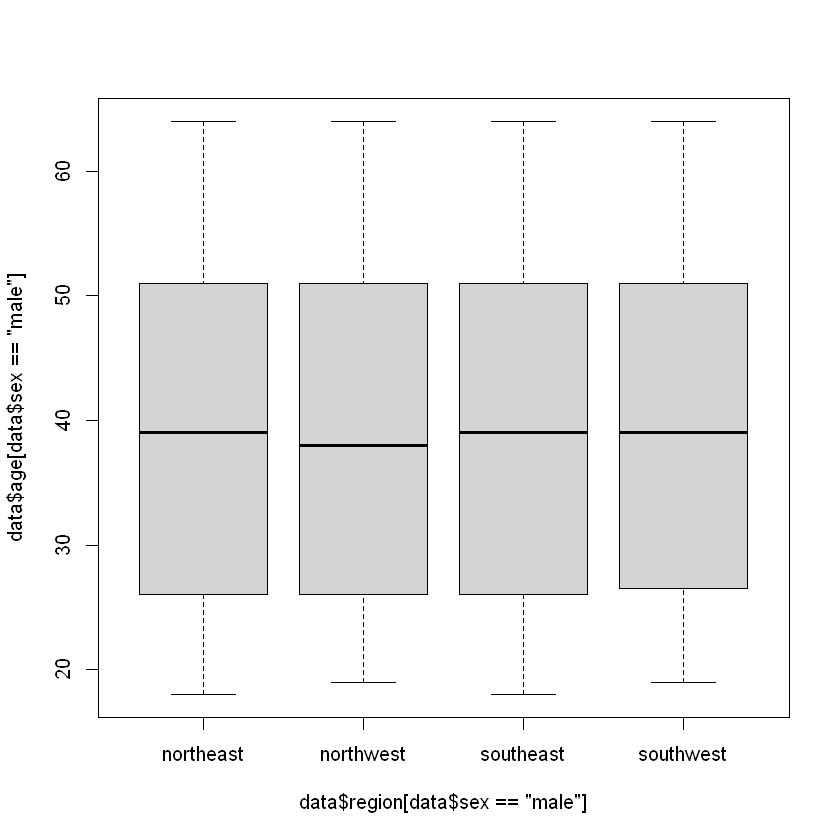

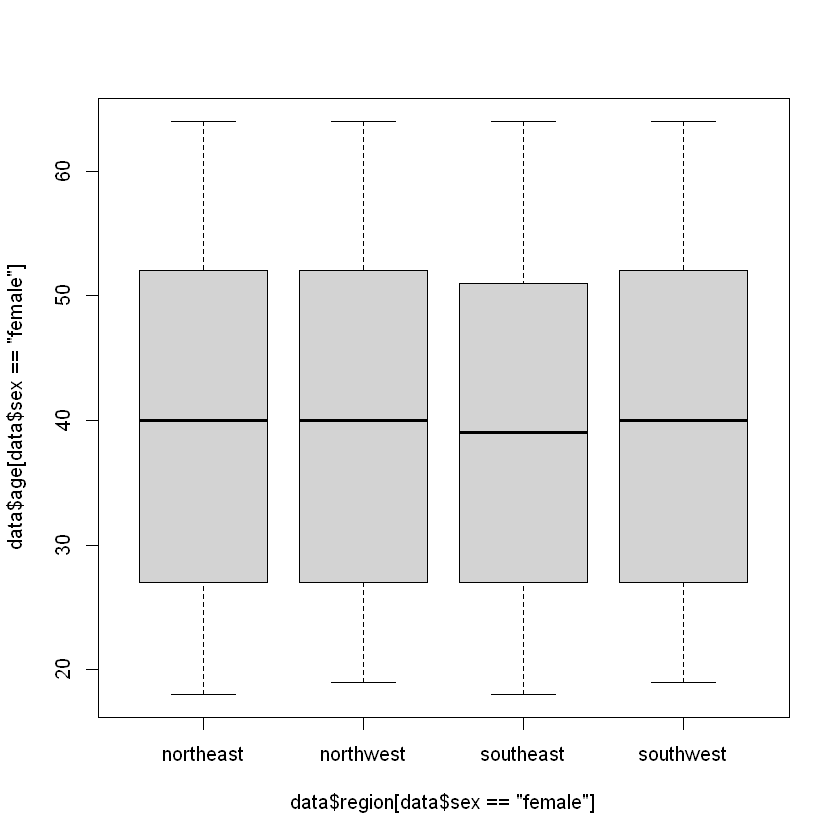

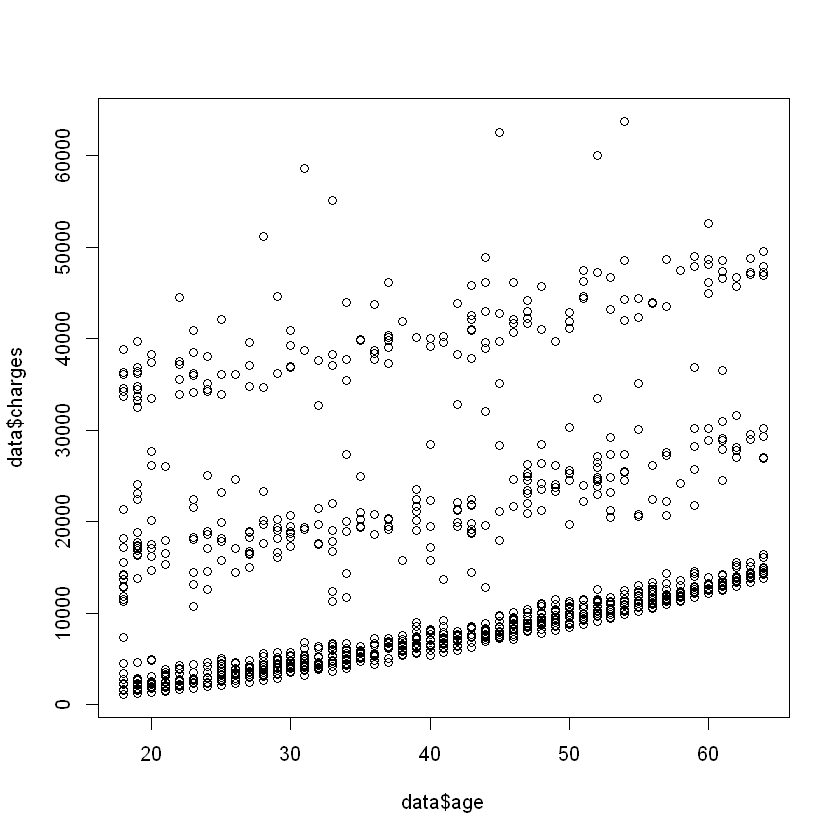

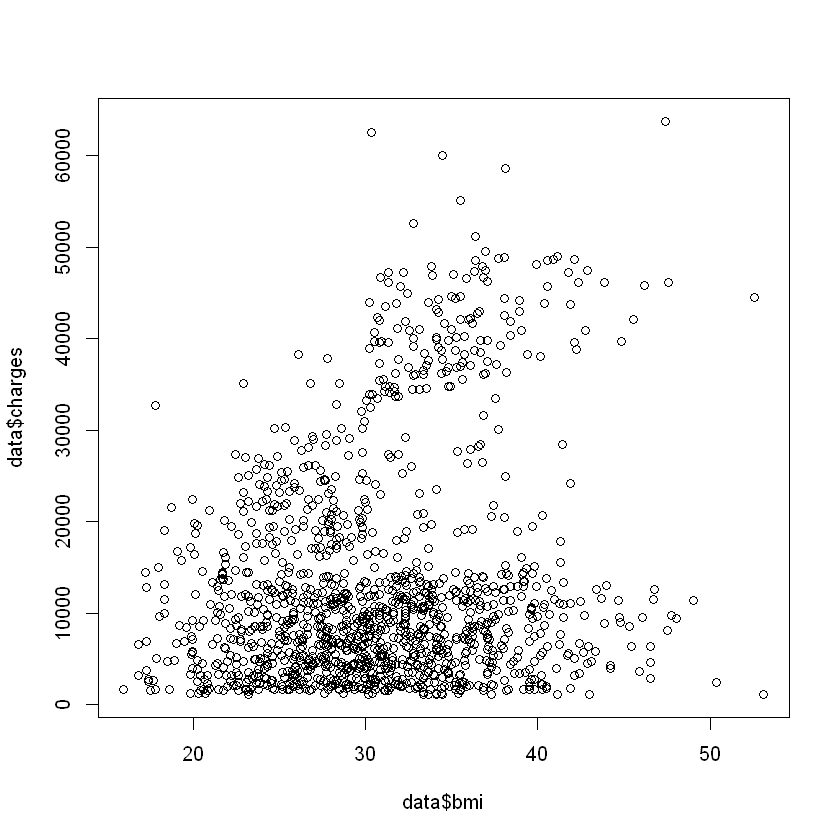

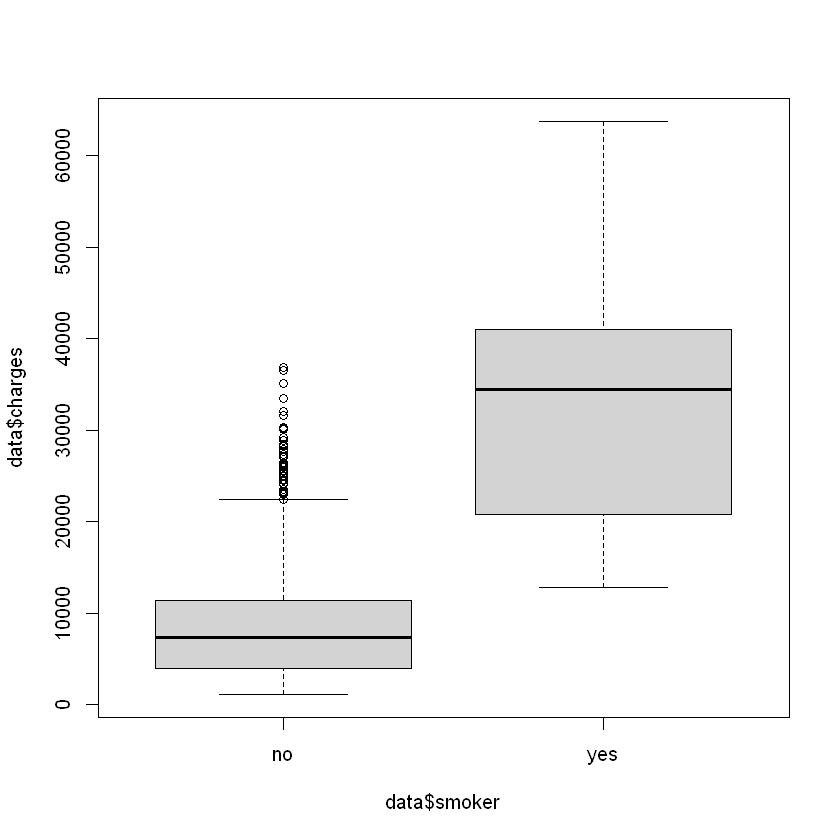

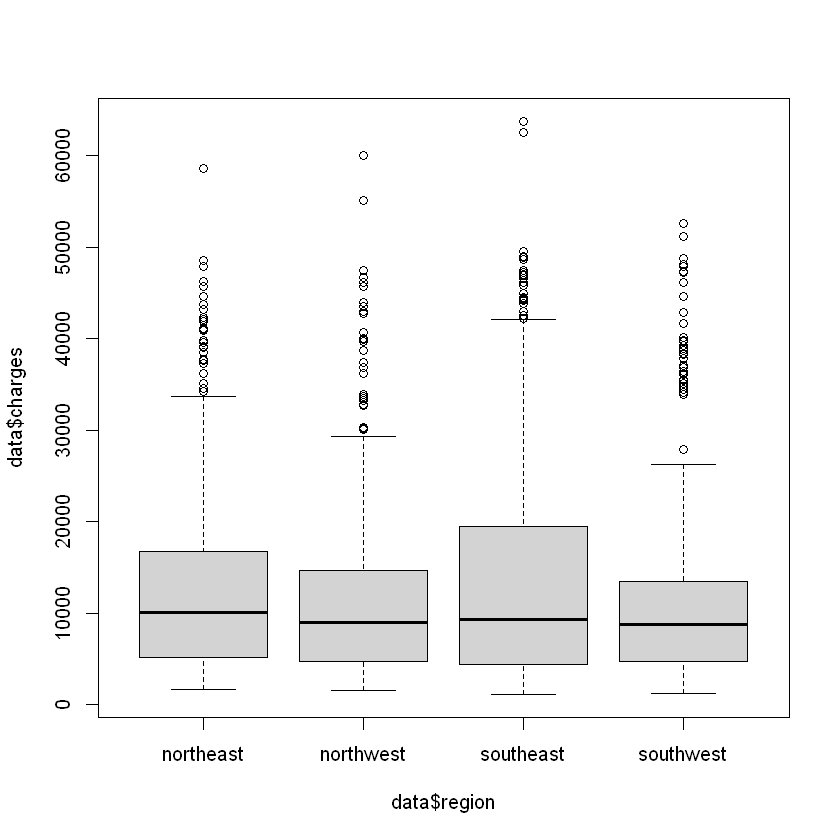

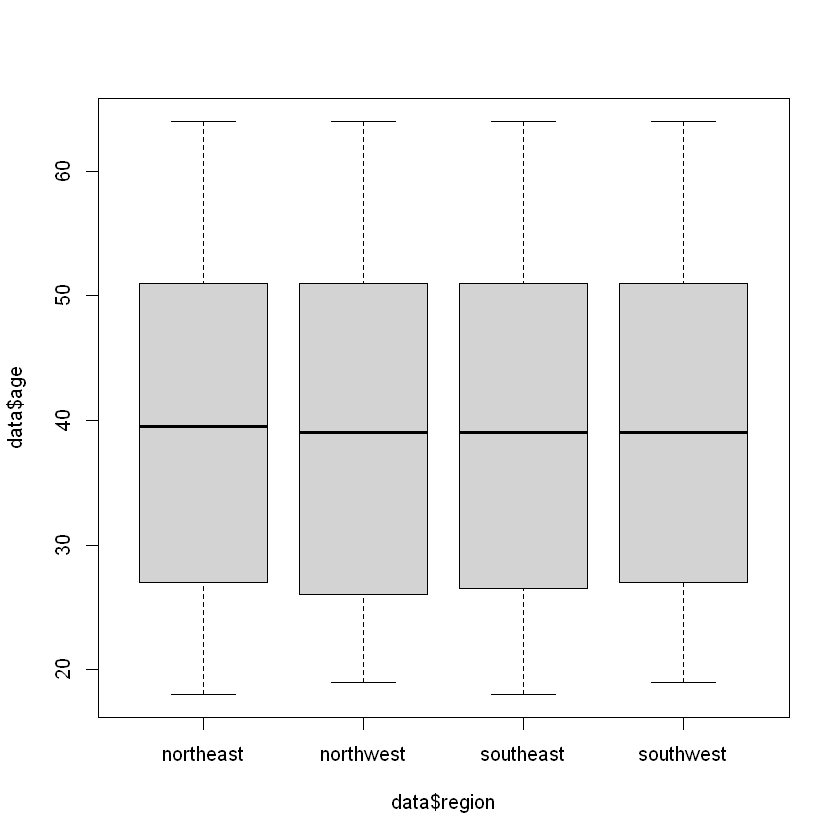

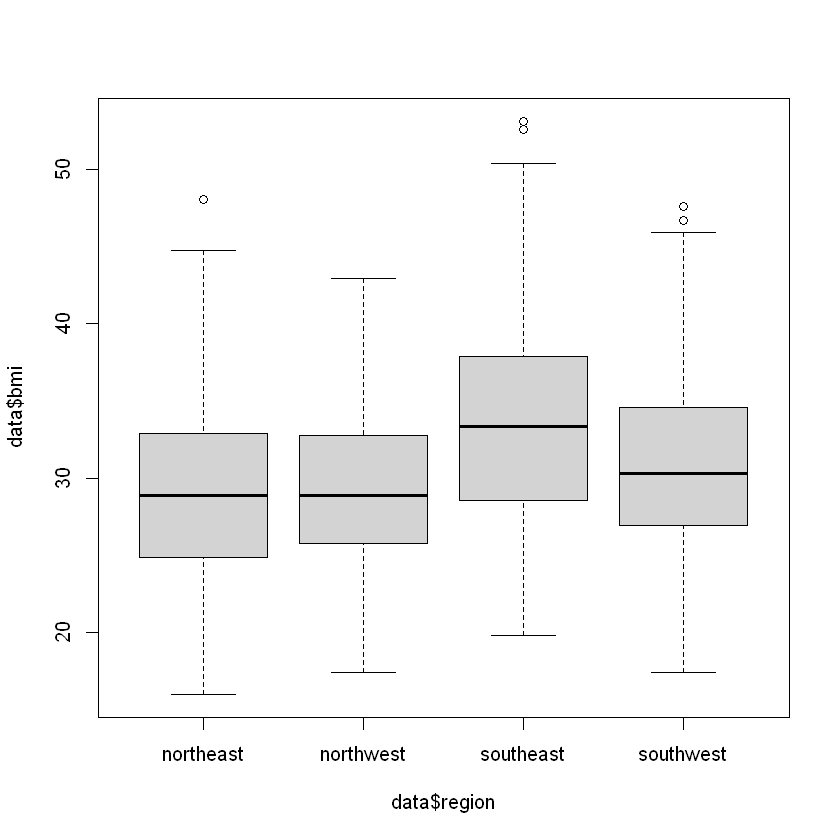

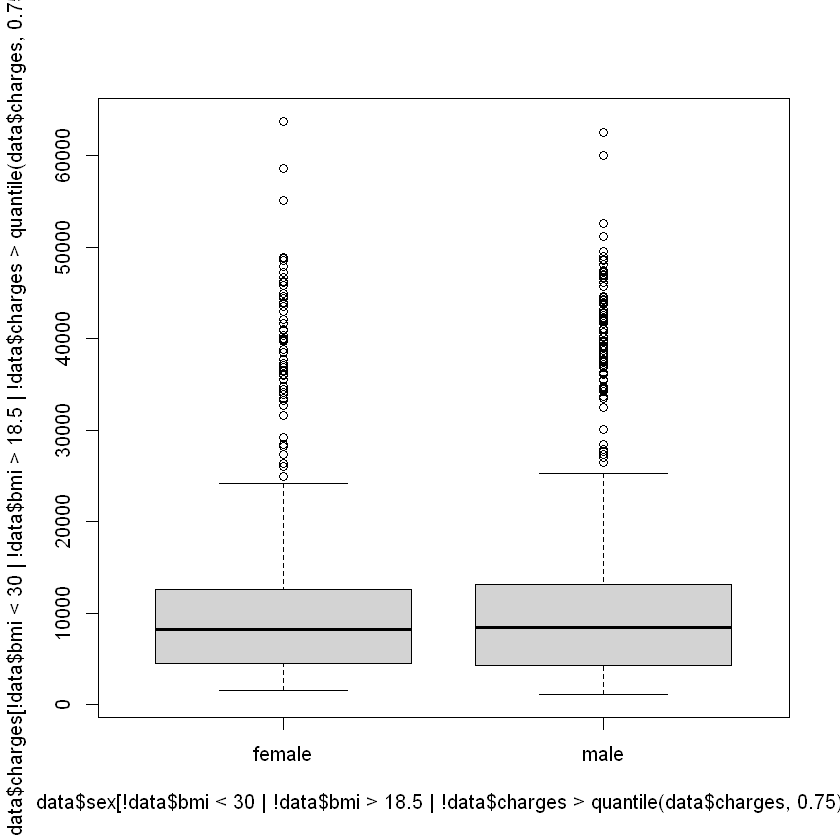

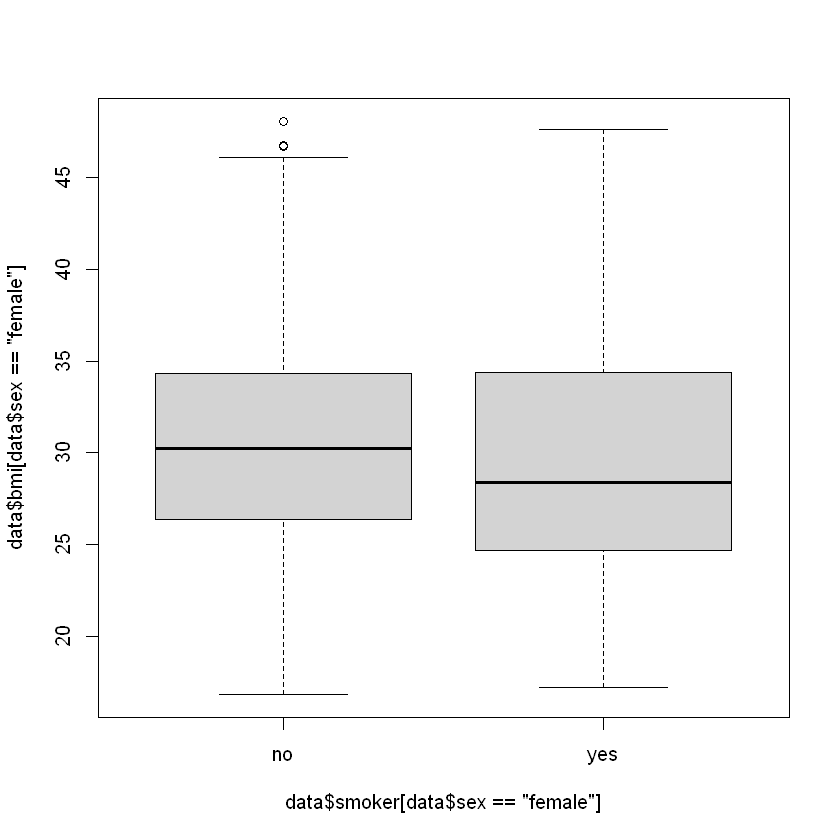

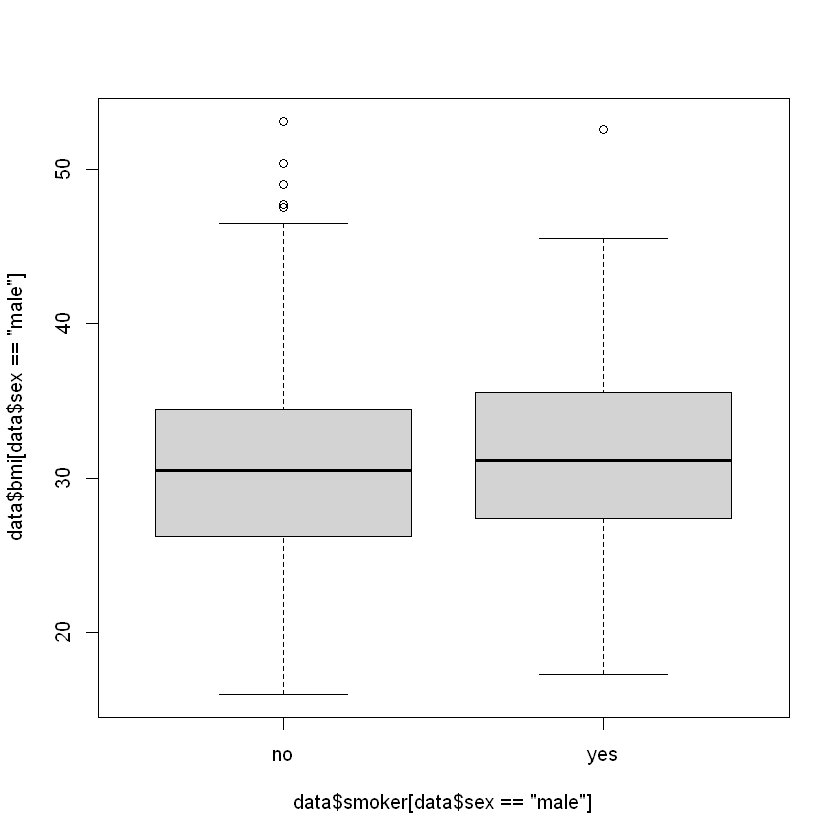

In [10]:
# 1. Représenter graphiquement l'âge des hommes selon leur région

boxplot(data$age[data$sex=="male"]~data$region[data$sex=="male"])

# 2. Pareil pour les femmes

boxplot(data$age[data$sex=="female"]~data$region[data$sex=="female"])

# 3. Représenter graphiquement les charges en fonction de l'âge

plot(data$age,data$charges)

# 4. Représenter graphiquement les charges en fonction du BMI

plot(data$bmi,data$charges)

# 5. Représenter graphiquement les charges selon que les individus fument ou pas
boxplot(data$charges~data$smoker)

# 6. Représenter graphiquement les charges en fonction des régions
boxplot(data$charges~data$region)

# 7. Représenter graphiquement l'âge en fonction des régions
boxplot(data$age~data$region)

# 8. Représenter graphiquement l'IMC en fonction du sexe.
boxplot(data$bmi~data$region)

# 9. Représenter graphiquement les charges selon le sexe, mais en excluant les IMC normaux et 
# les individus supérieurs au troisième quartile des charges.

boxplot(data$charges[!data$bmi < 30 | !data$bmi >18.5 | !data$charges>quantile(data$charges,0.75) ]~data$sex[!data$bmi < 30 | !data$bmi >18.5 | !data$charges>quantile(data$charges,0.75) ])

# 10. Représenter graphiquement l'IMC des femmes fumeuse et non-fumeuse.
boxplot(data$bmi[data$sex=="female"]~data$smoker[data$sex=="female"])

# 11. Représenter graphiquement l'IMC des hommes fumeur et non-fumeur.
boxplot(data$bmi[data$sex=="male"]~data$smoker[data$sex=="male"])


